# Data Collection and Exploration — NVIDIA Tweets Dataset

## 1. Import Libraries

This section imports the Python libraries needed for loading, checking, and visualising the NVIDIA tweets dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## 2. Load the Dataset

The dataset will be used to analyse NVIDIA-related social media attention, tweet sentiment, and network relationships between hashtags, cashtags, mentions and users.

The dataset was downloaded from Kaggle: “100K Nvidia Tweets”. It is a pre collected public dataset containing tweets related to NVIDIA. 

In [ ]:
file_path = "../data/sample/Nvidia-Tweets.csv"

df = pd.read_csv(file_path)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/Nvidia-Tweets.csv'

## 3. Check Dataset Size and Columns
This section checks the number of rows and columns in the dataset, it also displays the column names to understand what information is available for analysis.

In [ ]:
df.shape

(100847, 5)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Datetime', 'Tweet Id', 'Text', 'Username'], dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100847 entries, 0 to 100846
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  100847 non-null  str    
 1   Datetime    100369 non-null  str    
 2   Tweet Id    100001 non-null  float64
 3   Text        100001 non-null  str    
 4   Username    99633 non-null   str    
dtypes: float64(1), str(4)
memory usage: 3.8 MB


## 4. Check Missing Values

Missing values are checked to identify whether important fields such as tweet text, username, tweet ID, or datetime are incomplete.

In [ ]:
df.isnull().sum()

Unnamed: 0       0
Datetime       478
Tweet Id       846
Text           846
Username      1214
dtype: int64

## 5. Check Duplicate Data

In [ ]:
df.duplicated().sum()

np.int64(393)

In [ ]:
df["Tweet Id"].duplicated().sum()

np.int64(845)

In [ ]:
df["Text"].duplicated().sum()

np.int64(9756)

## 6. Convert Datetime Column

The `Datetime` column is converted into a proper datetime format, which allows the dataset to be analysed over time and later merged with NVIDIA stock price data.

In [ ]:
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

df[["Datetime"]].head()

,Datetime
0,2023-02-06 10:07:17+00:00
1,2023-02-06 10:06:30+00:00
2,2023-02-06 10:06:08+00:00
3,2023-02-06 10:05:43+00:00
4,2023-02-06 10:03:49+00:00


## 7. Check Dataset Time Period

This section checks the start and end dates of the tweet dataset, which is important because the time period of the NVIDIA stock price dataset must cover the same date range.

In [ ]:
start_date = df["Datetime"].min()
end_date = df["Datetime"].max()

start_date, end_date

(Timestamp('2022-11-21 14:30:16+0000', tz='UTC'),
 Timestamp('2023-02-06 10:07:17+0000', tz='UTC'))

## 8. Create Date Column

Created a separate `date` column from the full datetime value to makes it easier to count tweets per day and compare daily tweet activity with daily stock price movement.

In [ ]:
df["date"] = df["Datetime"].dt.date

df[["Datetime", "date"]].head()

,Datetime,date
0,2023-02-06 10:07:17+00:00,2023-02-06
1,2023-02-06 10:06:30+00:00,2023-02-06
2,2023-02-06 10:06:08+00:00,2023-02-06
3,2023-02-06 10:05:43+00:00,2023-02-06
4,2023-02-06 10:03:49+00:00,2023-02-06


## 9. Explore Top Users

This section checks which users appear most frequently in the dataset.  

In [ ]:
top_users = df["Username"].value_counts().head(10)

top_users

Username
nappedonthebed    5113
Smith28301        4113
FrenzyCapital     3524
vaikunt305        3277
Keanu5004         3270
Ajith5930         2739
skitontop1        2482
MURALIE622         971
philip30964        868
dowjone620         820
Name: count, dtype: int64

## 10. Count Tweets Per Day

Tweet counts are grouped by date to understand how NVIDIA related Twitter activity changes over time.

In [ ]:
tweets_per_day = df.groupby("date").size()

tweets_per_day.head()

date
2022-11-21     663
2022-11-22    1417
2022-11-23    1193
2022-11-24     883
2022-11-25     782
dtype: int64

In [ ]:
tweets_per_day.describe()

count      78.000000
mean     1282.064103
std       458.122633
min       322.000000
25%       826.500000
50%      1356.000000
75%      1613.750000
max      2277.000000
dtype: float64

## 11. Visualise Tweets Per Day

This line chart shows the number of NVIDIA related tweets per day which helps identify dates with higher or lower social media activity.

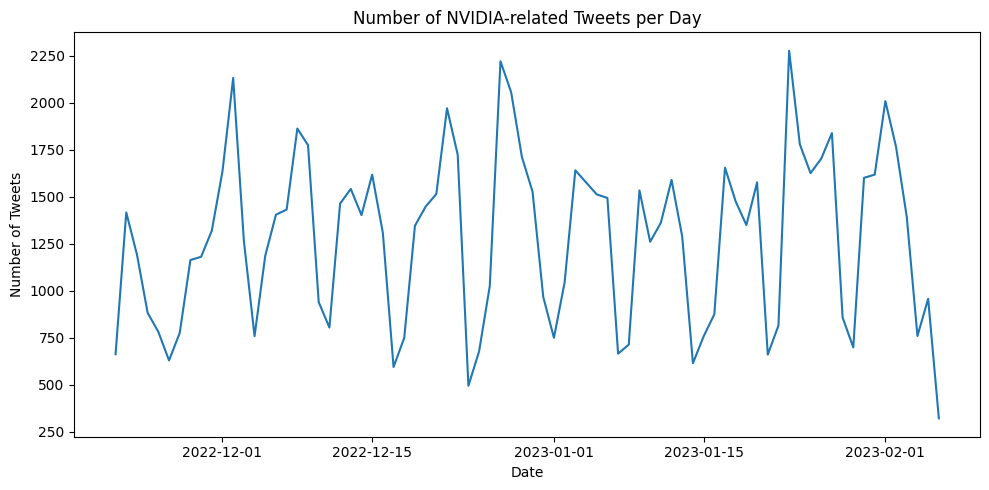

In [ ]:
plt.figure(figsize=(10, 5))

tweets_per_day.plot()

plt.title("Number of NVIDIA-related Tweets per Day")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.savefig("../outputs/figures/tweet_count_by_day.png")
plt.show()

## 12. Basic Dataset Summary

Created a small summary table containing the main dataset information.  

In [ ]:
summary_data = {
    "total_rows": [len(df)],
    "total_columns": [len(df.columns)],
    "start_date": [start_date],
    "end_date": [end_date],
    "unique_users": [df["Username"].nunique()],
    "duplicate_tweet_ids": [df["Tweet Id"].duplicated().sum()],
    "duplicate_texts": [df["Text"].duplicated().sum()]
}

summary_df = pd.DataFrame(summary_data)

summary_df

,total_rows,total_columns,start_date,end_date,unique_users,duplicate_tweet_ids,duplicate_texts
0,100847,6,2022-11-21 14:30:16+00:00,2023-02-06 10:07:17+00:00,8684,845,9756


In [ ]:
summary_df.to_csv("../outputs/tables/data_summary.csv", index=False)

## 13. Save Sample Dataset

A smaller sample of 1,000 tweets is saved into the `data/sample/` folder since the full raw dataset is too big to be pushed into Github


In [ ]:
sample_df = df.sample(n=1000, random_state=42)

sample_df.to_csv("../data/sample/nvidia_tweets_sample.csv", index=False)

sample_df.head()

,Unnamed: 0,Datetime,Tweet Id,Text,Username,date
9981,9900,2023-01-30 13:23:10+00:00,1.620050e+18,Trending: Nasdaq 100\n\n$AMZN -0.60 %\n$TSLA 0...,FrenzyCapital,2023-01-30
42177,41832,2023-01-05 13:06:38+00:00,1.610986e+18,$nvda ''' Top analyst price target for stocks...,smith42916050,2023-01-05
88322,87556,2022-12-02 12:57:54+00:00,1.598663e+18,Don't miss the next move in a few hours: https...,Dominic42422840,2022-12-02
1384,1368,2023-02-04 20:04:38+00:00,1.621963e+18,$ABBV $AMZN $DIS $JNJ $LLY $META $NVDA $PFE $T...,Beeken_health,2023-02-04
20807,20639,2023-01-23 13:41:33+00:00,1.617518e+18,"“Most winning trading community, Get next winn...",Smith28301,2023-01-23


## 14. Clean Dataset

This section cleans the NVIDIA tweets dataset by removing unnecessary columns, missing values and duplicate tweet.

In [ ]:
cleaned_df = df.copy()

#drop unnecessary index column
if 'Unnamed: 0' in cleaned_df.columns:
    cleaned_df = cleaned_df.drop(columns=['Unnamed: 0'])

#remove rows with missing important values
cleaned_df = cleaned_df.dropna(subset=['Datetime', 'Tweet Id', 'Text', 'Username'])

#remove full duplicate rows
cleaned_df = cleaned_df.drop_duplicates()

#remove duplicate tweet IDs
cleaned_df = cleaned_df.drop_duplicates(subset=['Tweet Id'])

#remove rows where Datetime could not be converted
cleaned_df = cleaned_df.dropna(subset=['Datetime'])

#check dataset size before and after cleaning
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", cleaned_df.shape)

Original dataset shape: (100847, 6)
Cleaned dataset shape: (99633, 5)


## 15. Save Cleaned Processed Dataset

The checked dataset is saved into the `data/processed/` folder then this file will be used in the next notebook for text cleaning and sentiment analysis.

In [ ]:
cleaned_df.to_csv("../data/processed/nvidia_tweets_cleaned.csv", index=False)

## 16. Final Notes

The NVIDIA tweets dataset has now been loaded, checked, and prepared for the next stage of analysis.
